# Clasical ML model selection - Derived features - All selected

Just like in 06_classification_baseline.ipynb, I'm going to use the following models:
- Logistic Regression
- Random Forest
- XGBoost
- Support Vector Machines

Run with all features...

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay
)

import xgboost as xgb

import joblib
import json
from datetime import datetime
import os

import core.constants as c
from core.processing import ResultsModel, ResultModel
from core.utils import extract_subject_id
from core.evaluation import model_test_summary, pick_threshold
from core.model_selection import split_train_test_set
from core.evaluation import SklearnAPIPredictor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
SAVE_MODEL = False
MODEL_NAME = "baseline_all_base_features_final"

In [3]:
X_train = pd.read_csv(c.RICKD_MODEL_1_X_TRAIN_BASE_STANDARDISED, index_col=0)
y_train = pd.read_csv(c.RICKD_MODEL_1_Y_TRAIN_BASE_STANDARDISED, index_col=0)

X_test = pd.read_csv(c.RICKD_MODEL_1_X_TEST_BASE_STANDARDISED, index_col=0)
y_test = pd.read_csv(c.RICKD_MODEL_1_Y_TEST_BASE_STANDARDISED, index_col=0)

X_val = pd.read_csv(c.RICKD_MODEL_1_X_VAL_BASE_STANDARDISED, index_col=0)
y_val = pd.read_csv(c.RICKD_MODEL_1_Y_VAL_BASE_STANDARDISED, index_col=0)


print("="*30)
print("Train")
print("="*30)
print(f"X Dataset shape: {X_train.shape}")
print(f"X Columns: {list(X_train.columns)}")
display(X_train.head())

print(f"Y Dataset shape: {y_train.shape}")
print(f"Y Columns: {list(y_train.columns)}")
display(y_train.head())

# Class imbalance
print(f"Class distribution: {y_train['is_injured'].value_counts()}")
print(f"Class distribution: {y_train['is_injured'].value_counts(normalize=True)}")


print("\n" + "="*30)
print("Validation")
print("="*30)
print(f"X Dataset shape: {X_val.shape}")
print(f"X Columns: {list(X_val.columns)}")
display(X_val.head())

print(f"Y Dataset shape: {y_val.shape}")
print(f"Y Columns: {list(y_val.columns)}")
display(y_val.head())

# Class imbalance
print(f"Class distribution: {y_val['is_injured'].value_counts()}")
print(f"Class distribution: {y_val['is_injured'].value_counts(normalize=True)}")


Train
X Dataset shape: (1254, 89)
X Columns: ['speed_output', 'step_width_left', 'step_width_right', 'stride_rate_left', 'stride_rate_right', 'stride_length_left', 'stride_length_right', 'swing_time_left', 'swing_time_right', 'stance_time_left', 'stance_time_right', 'pelvis_peak_drop_angle_left', 'pelvis_peak_drop_angle_right', 'pelvis_drop_excursion_left', 'pelvis_drop_excursion_right', 'ankle_df_peak_angle_left', 'ankle_df_peak_angle_right', 'ankle_eve_peak_angle_left', 'ankle_eve_peak_angle_right', 'ankle_eve_percent_stance_left', 'ankle_eve_percent_stance_right', 'ankle_eve_excursion_left', 'ankle_eve_excursion_right', 'ankle_rot_peak_angle_left', 'ankle_rot_peak_angle_right', 'ankle_rot_excursion_left', 'ankle_rot_excursion_right', 'knee_flex_peak_angle_left', 'knee_flex_peak_angle_right', 'knee_add_peak_angle_left', 'knee_add_peak_angle_right', 'knee_add_excursion_left', 'knee_add_excursion_right', 'knee_abd_peak_angle_left', 'knee_abd_peak_angle_right', 'knee_abd_excursion_left'

,speed_output,step_width_left,step_width_right,stride_rate_left,stride_rate_right,stride_length_left,stride_length_right,swing_time_left,swing_time_right,stance_time_left,...,vertical_oscillation_left,vertical_oscillation_right,age,height,weight,gender_female,gender_male,dominantleg_ambidextrous,dominantleg_left,dominantleg_right
id,,,,,,,,,,,,,,,,,,,,,
100001_20110531T161051,-0.544973,2.028758,2.028758,-0.850561,-0.853631,-0.276116,-0.275732,0.168299,-0.179392,0.762296,...,0.620751,0.322345,0.714694,-0.040127,-0.639845,1.0,0.0,0.0,1.0,0.0
100003_20110601T095930,0.438988,1.207229,1.207229,-0.850561,-0.853631,0.852776,0.854871,0.483358,0.452037,0.609877,...,-0.230834,-0.648272,1.042651,1.484500,1.266247,0.0,1.0,0.0,0.0,1.0
100004_20110203T120721,-0.120393,-1.490864,-1.490864,-0.210993,-0.212846,-0.049014,-0.048286,0.294322,0.830895,-0.152216,...,0.382947,-0.243505,-0.269179,0.351920,-0.864547,0.0,1.0,0.0,1.0,0.0
100004_20140929T102035,0.393478,-0.937232,-0.937232,0.014040,-0.100893,0.422845,0.471575,-0.209771,0.073180,0.152621,...,0.066412,-0.740602,0.058779,0.286579,-0.709580,0.0,1.0,0.0,1.0,0.0
100006_20110209T104505,0.399181,1.018287,1.018287,0.728275,0.728211,0.145497,0.146520,0.042276,-0.053106,-0.914309,...,-0.441665,-0.500731,0.222757,0.504383,0.840089,0.0,1.0,0.0,0.0,1.0


Y Dataset shape: (1254, 1)
Y Columns: ['is_injured']


,is_injured
id,
100001_20110531T161051,True
100003_20110601T095930,True
100004_20110203T120721,True
100004_20140929T102035,False
100006_20110209T104505,True


Class distribution: is_injured
True     803
False    451
Name: count, dtype: int64
Class distribution: is_injured
True     0.640351
False    0.359649
Name: proportion, dtype: float64

Validation
X Dataset shape: (192, 89)
X Columns: ['speed_output', 'step_width_left', 'step_width_right', 'stride_rate_left', 'stride_rate_right', 'stride_length_left', 'stride_length_right', 'swing_time_left', 'swing_time_right', 'stance_time_left', 'stance_time_right', 'pelvis_peak_drop_angle_left', 'pelvis_peak_drop_angle_right', 'pelvis_drop_excursion_left', 'pelvis_drop_excursion_right', 'ankle_df_peak_angle_left', 'ankle_df_peak_angle_right', 'ankle_eve_peak_angle_left', 'ankle_eve_peak_angle_right', 'ankle_eve_percent_stance_left', 'ankle_eve_percent_stance_right', 'ankle_eve_excursion_left', 'ankle_eve_excursion_right', 'ankle_rot_peak_angle_left', 'ankle_rot_peak_angle_right', 'ankle_rot_excursion_left', 'ankle_rot_excursion_right', 'knee_flex_peak_angle_left', 'knee_flex_peak_angle_right', 'knee_

,speed_output,step_width_left,step_width_right,stride_rate_left,stride_rate_right,stride_length_left,stride_length_right,swing_time_left,swing_time_right,stance_time_left,...,vertical_oscillation_left,vertical_oscillation_right,age,height,weight,gender_female,gender_male,dominantleg_ambidextrous,dominantleg_left,dominantleg_right
id,,,,,,,,,,,,,,,,,,,,,
100002_20110601T140505,-0.046333,-0.814664,-0.814664,-0.321214,-0.323276,0.076496,0.077414,0.420346,-0.179392,-0.152216,...,0.006970,0.465700,-0.105200,0.112336,0.034261,0.0,1.0,0.0,1.0,0.0
100013_20110323T140900,0.390726,1.435872,1.435872,0.128917,0.127711,0.372660,0.374027,-0.083748,0.325752,-0.304635,...,-0.166216,0.385552,0.386736,0.765747,-0.058719,0.0,1.0,0.0,1.0,0.0
100022_20110418T115212,0.496847,-0.798738,-0.798738,-0.042607,0.012616,0.559195,0.536811,0.924439,0.957181,-1.066728,...,0.763007,0.675285,-1.417030,-0.443064,-0.895540,0.0,1.0,0.0,0.0,1.0
100034_20110525T141002,-0.038219,-1.942342,-1.942342,-0.537216,-0.539689,0.173411,0.174475,1.302509,1.209752,-1.066728,...,0.609414,0.915978,0.304747,0.373700,-0.004481,0.0,1.0,0.0,0.0,1.0
100054_20110622T135245,-0.008554,2.101479,2.101479,-0.429944,-0.432214,0.162594,0.163642,0.546369,0.452037,0.000203,...,-0.529816,0.424148,-0.679126,1.255806,1.289492,0.0,1.0,0.0,0.0,1.0


Y Dataset shape: (192, 1)
Y Columns: ['is_injured']


,is_injured
id,
100002_20110601T140505,True
100013_20110323T140900,True
100022_20110418T115212,True
100034_20110525T141002,True
100054_20110622T135245,True


Class distribution: is_injured
True     124
False     68
Name: count, dtype: int64
Class distribution: is_injured
True     0.645833
False    0.354167
Name: proportion, dtype: float64


In [4]:
neg_pos_ratio = y_train['is_injured'].value_counts().iloc[0] / y_train['is_injured'].value_counts().iloc[1]
print(f"Negative to positive ratio: {neg_pos_ratio}")

models_config = {
    'Logistic Regression': {
        'pipeline': Pipeline([
            ('classifier', LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced'))
        ]),
        'param_grid': {
            'classifier__C': np.logspace(-3, 3, 7),
            'classifier__penalty': ['l1', 'l2'],
            'classifier__solver': ['liblinear']
        }
    },
    
    'Random Forest': {
        'pipeline': Pipeline([
            ('classifier', RandomForestClassifier(random_state=RANDOM_STATE,  class_weight='balanced'))
        ]),
        'param_grid': {
            'classifier__n_estimators': [100, 200, 300],
            'classifier__max_depth': [None, 10, 20],
            'classifier__min_samples_split': [2, 5, 10, 16],
            'classifier__min_samples_leaf': [2, 5, 8],
            'classifier__max_features': ['sqrt', 'log2']
        }
    },
    
    'XGBoost': {
        'pipeline': Pipeline([
            ('classifier', xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', max_delta_step=1))
        ]),
        'param_grid': {
            'classifier__n_estimators': [100, 200, 500],
            'classifier__max_depth': [3, 6, 9],
            'classifier__learning_rate': [0.005, 0.01, 0.1],
            'classifier__subsample': [0.8, 1.0],  # Add randomess for colinearity
            'classifier__colsample_bytree': [0.8, 1.0],
            'classifier__gamma': [0, 1, 5],
            'classifier__scale_pos_weight': [neg_pos_ratio]  # For class imbalance - See https://xgboost.readthedocs.io/en/stable/tutorials/param_tuning.html#handle-imbalanced-dataset
        }
    },
    'SVM': {
        'pipeline': Pipeline([
            ('classifier', SVC(random_state=RANDOM_STATE, probability=True, class_weight='balanced'))
        ]),
        'param_grid': {
            'classifier__C': [0.1, 1, 10],
            'classifier__kernel': ['rbf', 'linear', 'poly'],
            'classifier__gamma': ['scale', 0.1, 0.01]
        }
    }
}

Negative to positive ratio: 1.7804878048780488


In [5]:
print("SHPAES")
print("X_train: ", X_train.shape)
print("y_train: ", y_train.shape)
print("X_val: ", X_val.shape)
print("y_val: ", y_val.shape)

SHPAES
X_train:  (1254, 89)
y_train:  (1254, 1)
X_val:  (192, 89)
y_val:  (192, 1)


In [6]:
from sklearn.model_selection import StratifiedGroupKFold
import pickle
from pathlib import Path

# Train set for the best parameter model
X_train_all = pd.concat([X_train, X_val])
y_train_all = pd.concat([y_train, y_val])

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
groups_train = extract_subject_id(X_train.index.to_series())

trained_models = {}
results = {}

folder_path = Path(f"{c.RICKD_MODELS_FOLDER}/{MODEL_NAME}")
folder_path.mkdir(parents=True, exist_ok=True)

if SAVE_MODEL:
    for model_name, config in models_config.items():
        print('\n' + '='*30)
        print(f"Training {model_name}...")
        print('='*30)    
        grid_search = GridSearchCV(
            estimator=config['pipeline'],
            param_grid=config['param_grid'],
            cv = cv,
            scoring='roc_auc',
            n_jobs=-1,
            verbose=1,
        )

        # Hyperparameter tuning with train set
        grid_search.fit(X_train, y_train.values.ravel(), groups=groups_train)

        # Train best parameters model on full train+val
        best_model = grid_search.best_estimator_
        best_model.fit(X_train_all, y_train_all.values.ravel())

        # Find best threshold from validation set
        y_pred_proba_val = best_model.predict_proba(X_val)[:, 1]
        best_threshold, stats = pick_threshold(y_val, y_pred_proba_val, method="macro")  # Macro is good for imbalanced data
        print(f"Best threshold (val): {best_threshold}")


        # Save best results:
        trained_models[model_name] = best_model
        results[model_name] = {
            'best_threshold': best_threshold,
            'best_score': grid_search.best_score_,
            'best_params': grid_search.best_params_,
            'cv_results': grid_search.cv_results_,
        }
        
        print(f"Best CV Score: {grid_search.best_score_:.4f}")
        print(f"Best Parameters: {grid_search.best_params_}")
    with open(f"{folder_path}/trained_models.pkl", "wb") as f:
        pickle.dump(trained_models, f)
else:
    print("Loading results and trained models...")
    with open(f"{folder_path}/results.pkl", "rb") as f:
        results = pickle.load(f)
    
    with open(f"{folder_path}/trained_models.pkl", "rb") as f:
        trained_models = pickle.load(f)
    
    for model_name, model_results in results.items():
        print('\n' + '='*30)
        print(f"Model: {model_name}")
        print('='*30)
        print(f"Best threshold (val): {model_results['best_threshold']}")
        print(f"Best CV Score: {model_results['best_score']:.4f}")
        print(f"Best Parameters: {model_results['best_params']}")


Training Logistic Regression...
Fitting 5 folds for each of 14 candidates, totalling 70 fits


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Per

Best threshold (val): 0.37765006352022934
Best CV Score: 0.7239
Best Parameters: {'classifier__C': np.float64(0.1), 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}

Training Random Forest...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best threshold (val): 0.6089654117450478
Best CV Score: 0.7357
Best Parameters: {'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}

Training XGBoost...
Fitting 5 folds for each of 324 candidates, totalling 1620 fits


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best threshold (val): 0.7413100600242615
Best CV Score: 0.7569
Best Parameters: {'classifier__colsample_bytree': 1.0, 'classifier__gamma': 1, 'classifier__learning_rate': 0.005, 'classifier__max_depth': 6, 'classifier__n_estimators': 500, 'classifier__scale_pos_weight': np.float64(1.7804878048780488), 'classifier__subsample': 0.8}

Training SVM...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best threshold (val): 0.5549843897705032
Best CV Score: 0.7259
Best Parameters: {'classifier__C': 1, 'classifier__gamma': 0.01, 'classifier__kernel': 'rbf'}


X_test shape: (367, 89)
y_test shape: (367, 1)


Model: Logistic Regression
MODEL EVALUATION RESULTS
=== Test Prevalence: 61.04 ===
Test AUC-PR : 0.6666
Test AUC-ROC : 0.6145
=== Threshold Dependent Metrics ===
=== Threshold: 0.38 ===
Test Accuracy : 0.6594
Test F1-Macro Score : 0.5974
Test Precision : 0.6725
Test Recall : 0.8616

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     Injured       0.67      0.86      0.76       224
 Not Injured       0.61      0.34      0.44       143

    accuracy                           0.66       367
   macro avg       0.64      0.60      0.60       367
weighted avg       0.65      0.66      0.63       367


Model: Random Forest
MODEL EVALUATION RESULTS
=== Test Prevalence: 61.04 ===
Test AUC-PR : 0.6910
Test AUC-ROC : 0.6225
=== Threshold Dependent Metrics ===
=== Threshold: 0.61 ===
Test Accuracy : 0.5995
Test F1-Macro Score : 0.5834
Test Precision : 0.6791
Test Recall : 0.6518

=== CLASSIFICATION REPORT ===
 

/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Per


Model: SVM
MODEL EVALUATION RESULTS
=== Test Prevalence: 61.04 ===
Test AUC-PR : 0.6757
Test AUC-ROC : 0.6330
=== Threshold Dependent Metrics ===
=== Threshold: 0.55 ===
Test Accuracy : 0.6240
Test F1-Macro Score : 0.5993
Test Precision : 0.6838
Test Recall : 0.7143

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     Injured       0.68      0.71      0.70       224
 Not Injured       0.52      0.48      0.50       143

    accuracy                           0.62       367
   macro avg       0.60      0.60      0.60       367
weighted avg       0.62      0.62      0.62       367



<Figure size 640x480 with 0 Axes>

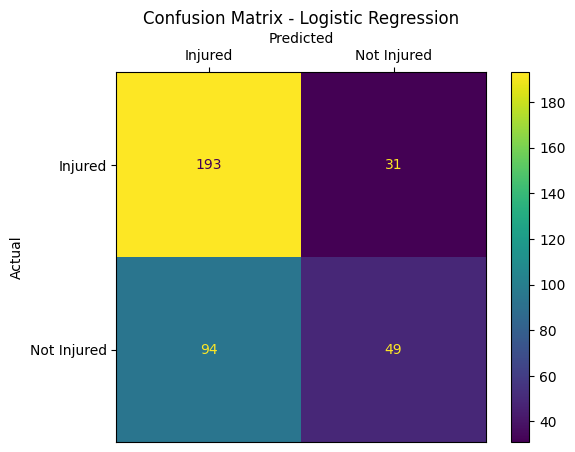

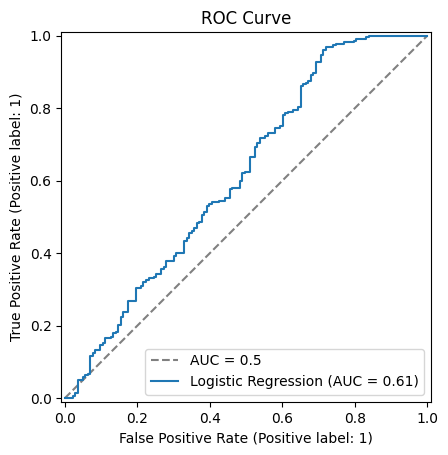

<Figure size 640x480 with 0 Axes>

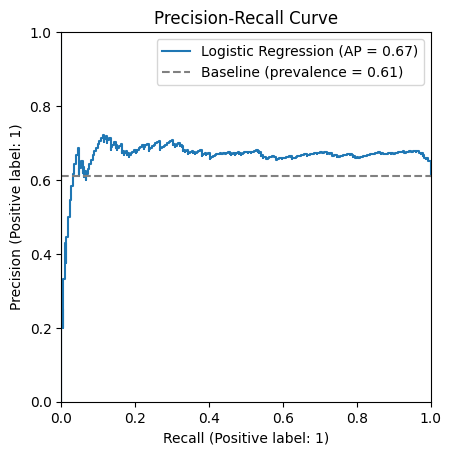

<Figure size 640x480 with 0 Axes>

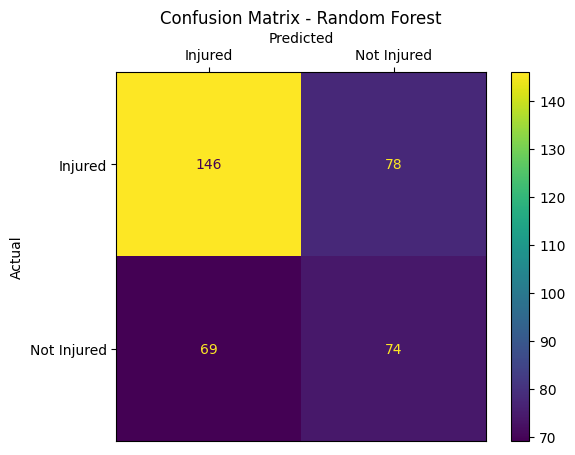

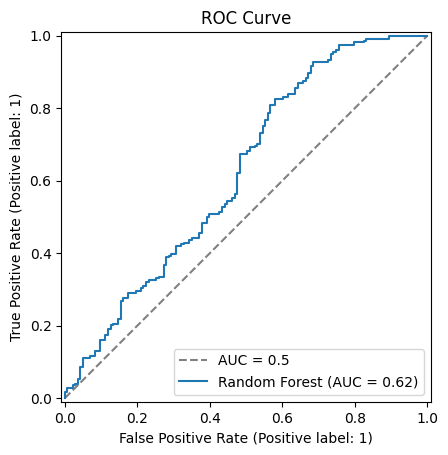

<Figure size 640x480 with 0 Axes>

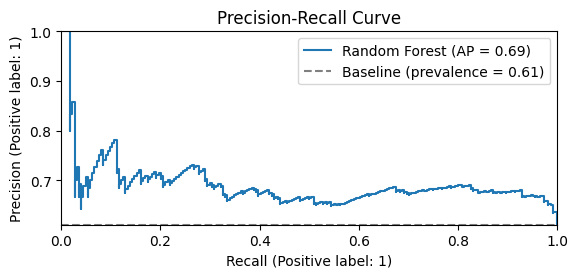

<Figure size 640x480 with 0 Axes>

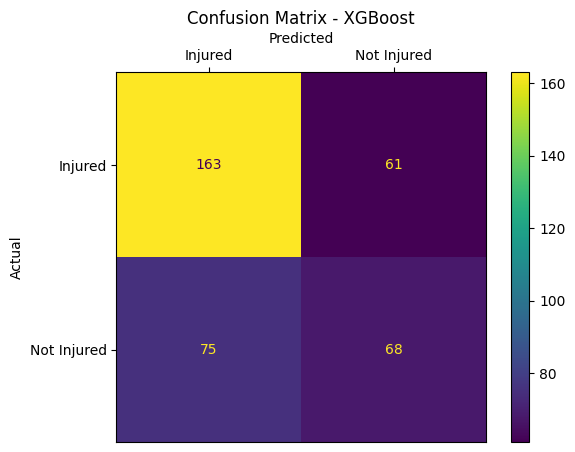

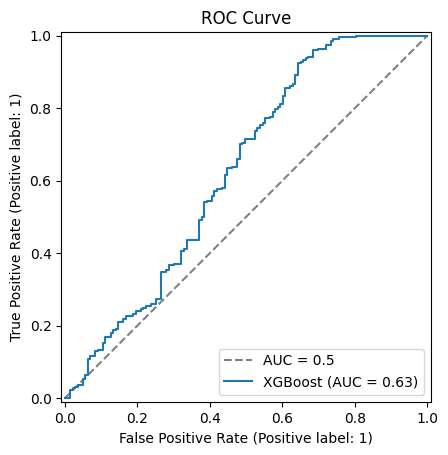

<Figure size 640x480 with 0 Axes>

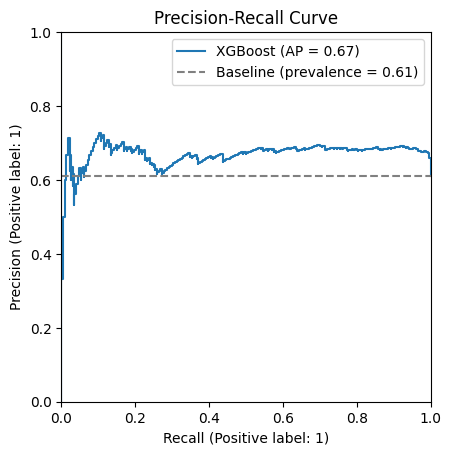

<Figure size 640x480 with 0 Axes>

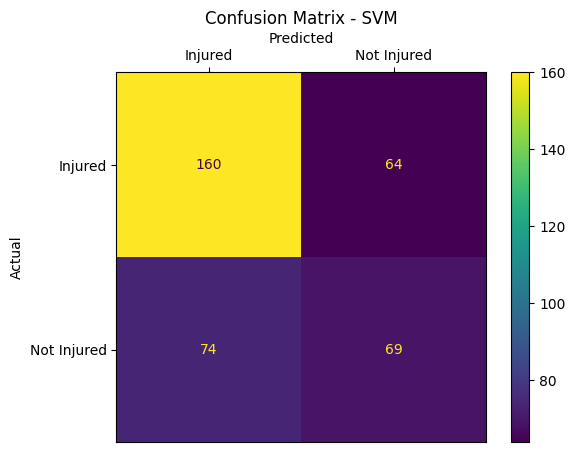

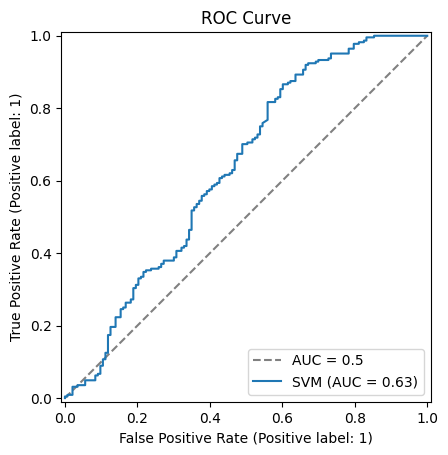

<Figure size 640x480 with 0 Axes>

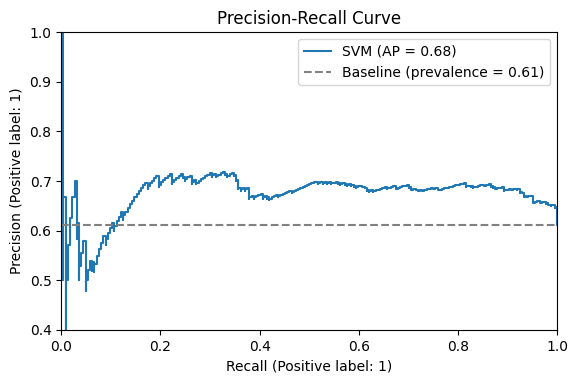

In [7]:
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print()


for model_name, model in trained_models.items():
    print('\n' + '='*50)
    print(f"Model: {model_name}")
    best_threshold = results[model_name]['best_threshold']
    pred = SklearnAPIPredictor(model)
    test_summary = model_test_summary(model, X_test, y_test,
        threshold=best_threshold,
        predictor=pred,
        model_name=model_name,
        save_predictions=True,
    )
    
    results[model_name].update(test_summary)

Model Performance Comparison by Test ROC AUC:
                 Model  Test ROC AUC  Test PR AUC  Test Accuracy  \
3                  SVM        0.6330       0.6757         0.6240   
2              XGBoost        0.6267       0.6712         0.6294   
1        Random Forest        0.6225       0.6910         0.5995   
0  Logistic Regression        0.6145       0.6666         0.6594   

   Test Precision  Test Recall  Test F1-Score  Test Prevalence  Test Threshold  
3          0.6838       0.7143         0.5993           0.6104          0.5550  
2          0.6849       0.7277         0.6028           0.6104          0.7413  
1          0.6791       0.6518         0.5834           0.6104          0.6090  
0          0.6725       0.8616         0.5974           0.6104          0.3777  

Best performing model: SVM
Best Test ROC AUC Score: 0.6330


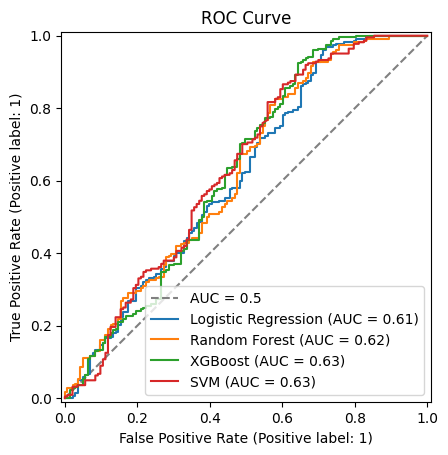

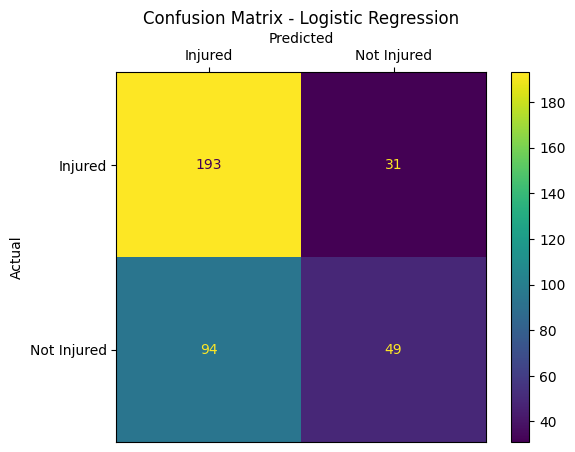

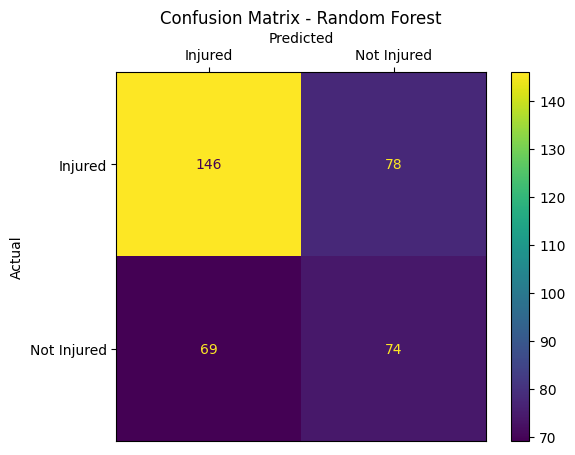

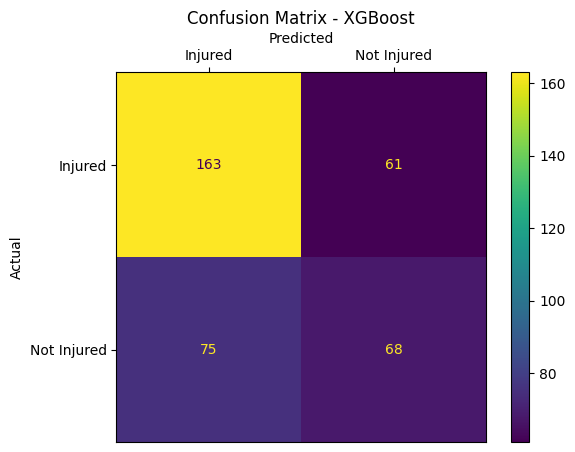

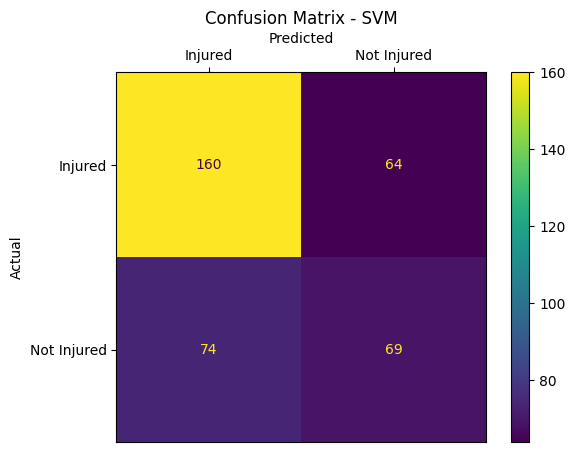

In [8]:
comparison_data = []
ax = plt.gca()

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='AUC = 0.5')

for model_name, result in results.items():
    comparison_data.append({
        'Model': model_name,
        'Test ROC AUC': result['auc_roc'],
        'Test PR AUC': result['auc_pr'],
        'Test Accuracy': result['accuracy'],
        'Test Precision': result['precision'],
        'Test Recall': result['recall'],
        'Test F1-Score': result['f1'],
        'Test Prevalence': result['prevalence'],
        'Test Threshold': result['threshold'],
    })
    roc_disp = RocCurveDisplay.from_predictions(
        y_test, 
        result['y_pred_proba'], 
        name=model_name,
        ax=ax,
    )
roc_disp.ax_.set_title('ROC Curve')

for model_name, result in results.items():
    class_labels = ['Injured', 'Not Injured']
    cm_disp = ConfusionMatrixDisplay.from_predictions(
        y_test, 
        result['y_pred'], 
        display_labels=class_labels,
        labels=[1, 0]
    )
    cm_disp.ax_.xaxis.set_label_position('top')
    cm_disp.ax_.xaxis.set_ticks_position('top')
    cm_disp.ax_.xaxis.set_label_text('Predicted')
    cm_disp.ax_.yaxis.set_label_text('Actual')
    cm_disp.ax_.set_title(f'Confusion Matrix - {model_name}')

PRIMARY_METRIC = 'Test ROC AUC'
comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values(PRIMARY_METRIC, ascending=False)

print(f"Model Performance Comparison by {PRIMARY_METRIC}:")
print('='*50)
print(comparison_df.round(4))

best_model_name = comparison_df.iloc[0]['Model']
print(f"\nBest performing model: {best_model_name}")
print(f"Best {PRIMARY_METRIC} Score: {comparison_df.iloc[0][PRIMARY_METRIC]:.4f}")

In [9]:
import pickle
from pathlib import Path

if SAVE_MODEL:
    folder_path = Path(f"{c.RICKD_MODELS_FOLDER}/{MODEL_NAME}")
    folder_path.mkdir(parents=True, exist_ok=True)

    with open(f"{folder_path}/results.pkl", "wb") as f:
        pickle.dump(results, f)
